# O6 Multimodal — depth counter-check

Fixed depths 5, 10, 20, 30, and 40 compared with staged `3 → 6 → 9 → 20`.

In [8]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "02_counter_check":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/depth_policies/02_counter_check")
OUTPUT_DIRECTORY = HERE / "smac_output"
DEPTHS = (5, 10, 20, 30, 40)
FIXED = tuple(f"fixed_depth_{depth}" for depth in DEPTHS)
STAGED = "staged_depth_3_6_9_20"
POLICIES = FIXED + (STAGED,)
SEEDS = tuple(range(5))
N_TRIALS = 1000
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_depth_{depth}": f"depth = {depth}" for depth in DEPTHS}
LABELS[STAGED] = "staged 3 → 6 → 9 → 20"
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4", "black")))

In [9]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        seed = result["smac_seed"]
        if seed in SEEDS and result["n_trials"] == N_TRIALS:
            runs[seed] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing completed runs for {policy}: seeds={missing}")
    return runs

results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    for result in runs.values():
        assert result["problem"] == "O6-Multimodal"
        assert result["problem_seed"] == 52
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert len(result["best_regret"]) == N_TRIALS
        if policy in FIXED:
            assert result["max_depth"] == int(policy.rsplit("_", 1)[1])
        else:
            assert result["stage_boundaries"] == [100, 200, 500]
            assert result["depth_schedule"] == [3, 6, 9, 20]
print(f"Loaded {sum(map(len, results.values()))}/30 validated trajectories.")

Loaded 30/30 validated trajectories.


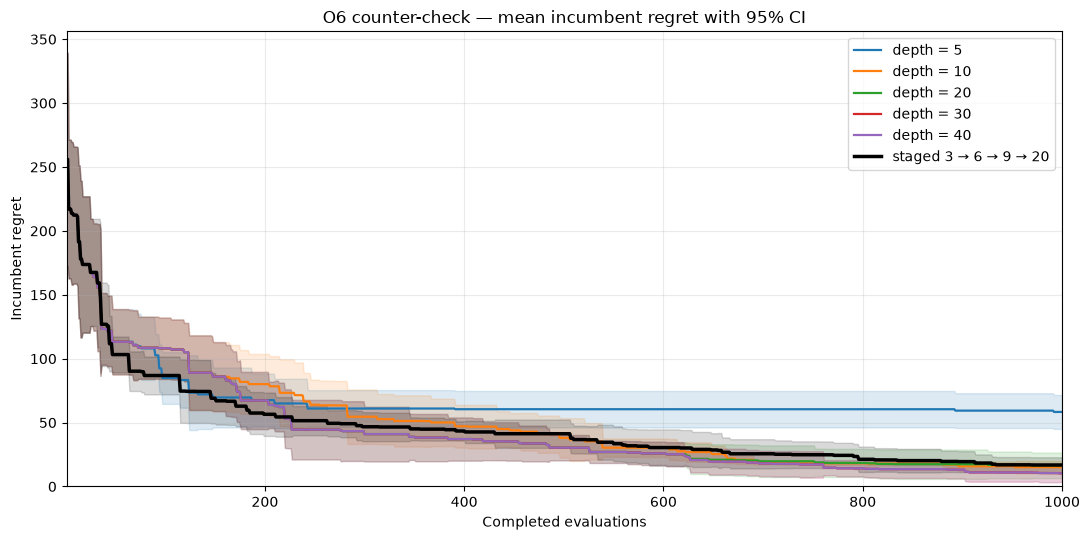

In [10]:
rows = [
    {"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret}
    for policy, runs in results.items()
    for seed, result in runs.items()
    for iteration, regret in zip(result["iteration"], result["best_regret"])
]
trajectories = pd.DataFrame(rows)
summary = (
    trajectories.groupby(["policy", "iteration"])["best_regret"]
    .agg(["mean", "std", "count"]).reset_index()
)
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(11, 5.5))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    width = 2.5 if policy == STAGED else 1.6
    ax.plot(data.iteration, data["mean"], label=LABELS[policy],
            color=COLORS[policy], linewidth=width)
    ax.fill_between(data.iteration,
                    np.maximum(0, data["mean"] - data.ci95),
                    data["mean"] + data.ci95,
                    color=COLORS[policy], alpha=0.15)
ax.set(title="O6 counter-check — mean incumbent regret with 95% CI",
       xlabel="Completed evaluations", ylabel="Incumbent regret",
       xlim=(1, N_TRIALS), ylim=(0, None))
ax.grid(alpha=0.25); ax.legend(); plt.tight_layout(); plt.show()

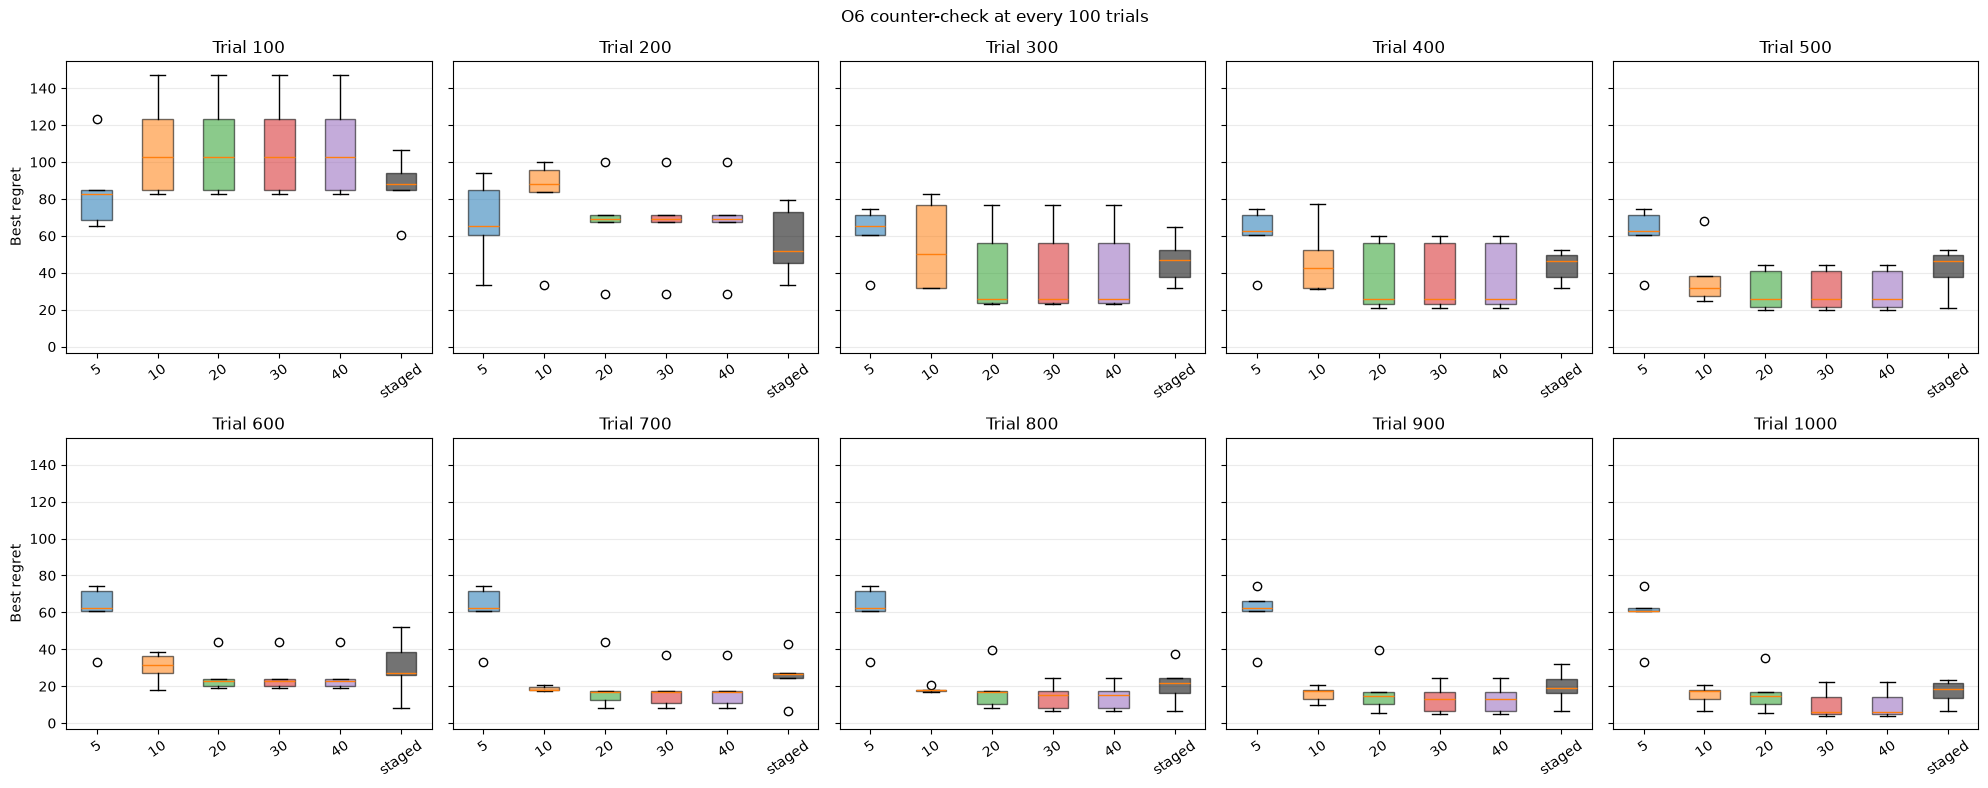

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1]
               for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True,
                       tick_labels=[str(depth) for depth in DEPTHS] + ["staged"])
    for box, policy in zip(boxes["boxes"], POLICIES):
        box.set(facecolor=COLORS[policy], alpha=0.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
for ax in axes[:, 0]: ax.set_ylabel("Best regret")
fig.suptitle("O6 counter-check at every 100 trials")
plt.tight_layout(); plt.show()

In [12]:
mean_regret = trajectories.pivot_table(
    index="iteration", columns="policy", values="best_regret", aggfunc="mean"
).reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame(
    {policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9)
     for policy in POLICIES}, index=mean_regret.index
)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum().reindex(POLICIES)
    maximum = int(counts.max())
    row = {
        "iterations": f"{end - 99}–{end}",
        "superior policy": ", ".join(
            LABELS[policy] for policy in POLICIES if counts[policy] == maximum
        ),
        "winning iterations": maximum,
    }
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES})
    block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
block_superiority

,iterations,superior policy,winning iterations,depth = 5,depth = 10,depth = 20,depth = 30,depth = 40,staged 3 → 6 → 9 → 20
0,1–100,staged 3 → 6 → 9 → 20,80,47,43,43,43,43,80
1,101–200,staged 3 → 6 → 9 → 20,64,36,0,0,0,0,64
2,201–300,"depth = 20, depth = 30, depth = 40",81,0,0,81,81,81,19
3,301–400,"depth = 20, depth = 30, depth = 40",100,0,0,100,100,100,0
4,401–500,"depth = 20, depth = 30, depth = 40",100,0,0,100,100,100,0
5,501–600,"depth = 20, depth = 30, depth = 40",100,0,0,100,100,100,0
6,601–700,"depth = 30, depth = 40",100,0,0,20,100,100,0
7,701–800,"depth = 30, depth = 40",100,0,0,0,100,100,0
8,801–900,"depth = 30, depth = 40",100,0,0,0,100,100,0
9,901–1000,"depth = 30, depth = 40",100,0,0,0,100,100,0


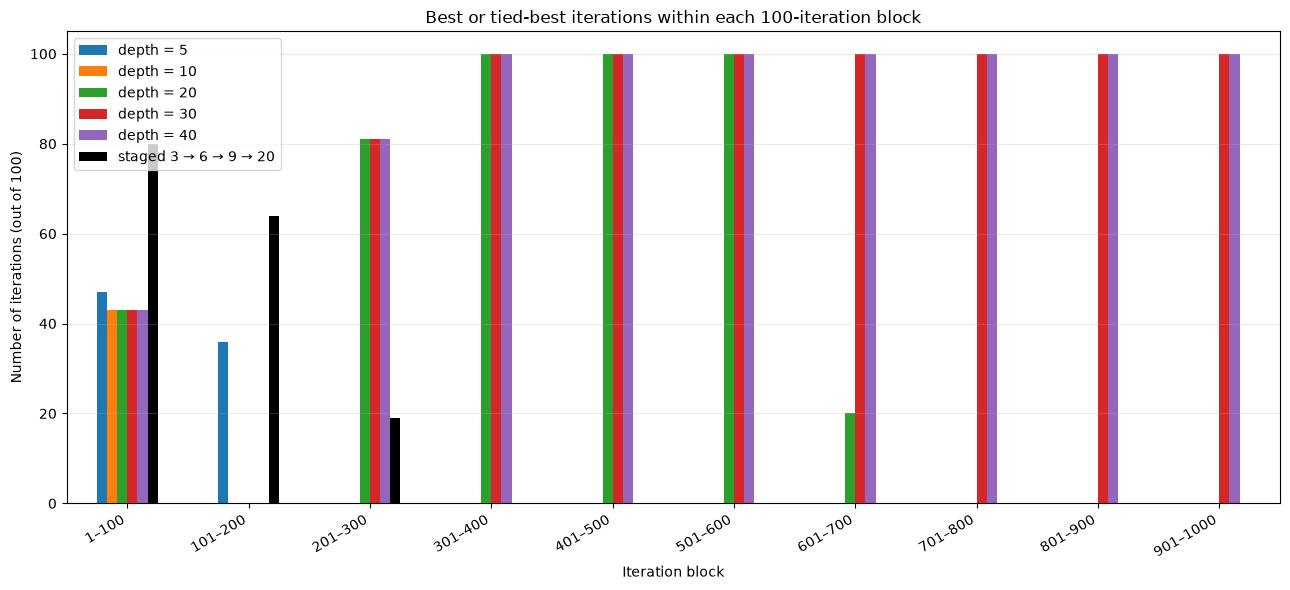

In [13]:
count_columns = [LABELS[policy] for policy in POLICIES]
ax = block_superiority.set_index("iterations")[count_columns].plot(
    kind="bar", figsize=(13, 6), color=[COLORS[policy] for policy in POLICIES]
)
ax.set(title="Best or tied-best iterations within each 100-iteration block",
       xlabel="Iteration block", ylabel="Number of iterations (out of 100)",
       ylim=(0, 105))
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

In [14]:
checkpoint_statistics = (
    trajectories[trajectories.iteration.isin(CHECKPOINTS)]
    .groupby(["iteration", "policy"])["best_regret"]
    .agg(["mean", "std", "min", "median", "max"])
)
with pd.option_context("display.max_rows", None,
                       "display.max_columns", None,
                       "display.width", None):
    display(checkpoint_statistics)

mean        std        min      median  \
iteration policy                                                                
100       fixed_depth_10         108.159702  27.374557  82.534547  103.001565   
          fixed_depth_20         108.159702  27.374557  82.534547  103.001565   
          fixed_depth_30         108.159702  27.374557  82.534547  103.001565   
          fixed_depth_40         108.159702  27.374557  82.534547  103.001565   
          fixed_depth_5           84.887057  23.103137  65.256062   82.534547   
          staged_depth_3_6_9_20   86.838565  16.881626  60.659200   87.953075   
200       fixed_depth_10          80.103495  26.954353  33.198932   87.975642   
          fixed_depth_20          67.294187  25.525637  28.332721   69.304093   
          fixed_depth_30          67.294187  25.525637  28.332721   69.304093   
          fixed_depth_40          67.294187  25.525637  28.332721   69.304093   
          fixed_depth_5           67.615069  23.665157  33.198932   65.256062   
          staged_depth_3_6_9_20   56.499911  19.377571  33.198932   51.698466   
300       fixed_depth_10          54.616038  24.297073  31.504710   49.926717   
          fixed_depth_20          41.006854  24.405855  22.895056   25.723058   
          fixed_depth_30          41.006854  24.405855  22.895056   25.723058   
          fixed_depth_40          41.006854  24.405855  22.895056   25.723058   
          fixed_depth_5           61.007917  16.440765  33.198932   65.256062   
          staged_depth_3_6_9_20   46.739703  12.988121  31.660035   47.162017   
400       fixed_depth_10          47.128762  19.090565  31.462149   42.804584   
          fixed_depth_20          37.113043  19.286737  20.755319   25.723058   
          fixed_depth_30          37.113043  19.286737  20.755319   25.723058   
          fixed_depth_40          37.113043  19.286737  20.755319   25.723058   
          fixed_depth_5           60.474266  16.311196  33.198932   62.587808   
          staged_depth_3_6_9_20   43.437139   8.555551  31.660035   46.220013   
500       fixed_depth_10          38.034266  17.639229  24.606674   31.504710   
          fixed_depth_20          30.403302  11.370824  19.958644   25.608928   
          fixed_depth_30          30.403302  11.370824  19.958644   25.608928   
          fixed_depth_40          30.403302  11.370824  19.958644   25.608928   
          fixed_depth_5           60.474266  16.311196  33.198932   62.587808   
          staged_depth_3_6_9_20   41.291390  12.625190  20.931289   46.220013   
600       fixed_depth_10          30.304963   8.185441  18.017533   31.504710   
          fixed_depth_20          25.931062  10.400082  18.782561   22.705912   
          fixed_depth_30          25.931062  10.400082  18.782561   22.705912   
          fixed_depth_40          25.931062  10.400082  18.782561   22.705912   
          fixed_depth_5           60.450457  16.291009  33.198932   62.587808   
          staged_depth_3_6_9_20   30.459501  16.242235   8.279458   27.271995   
700       fixed_depth_10          18.689193   1.302605  17.534490   17.936051   
          fixed_depth_20          19.763085  14.128120   7.971424   16.655437   
          fixed_depth_30          18.022152  11.309283   7.971424   16.732947   
          fixed_depth_40          18.022152  11.309283   7.971424   16.732947   
          fixed_depth_5           60.450457  16.291009  33.198932   62.587808   
          staged_depth_3_6_9_20   25.583359  13.026786   6.450590   26.684771   
800       fixed_depth_10          18.159497   1.336721  17.032109   17.827617   
          fixed_depth_20          18.443968  12.529010   7.971424   16.655437   
          fixed_depth_30          14.245507   7.293695   6.352704   15.367663   
          fixed_depth_40          14.245507   7.293695   6.352704   15.367663   
          fixed_depth_5           60.450457  16.291009  33.198932   62.587808   
          staged_depth_3_6_9_20   21.288658  11.352019   6.450590   21